<a href="https://colab.research.google.com/github/abeeraz379/literacy-rates-updated/blob/main/literacy_rates_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Literacy rates updated
- ABeer Al-Zebda | Data Scientist & Machine Learning Engineer

# Project Overview
- Literacy rate is calculated by taking the number of literate persons in that age and gender group divided by the total number of persons in that group. Literate is defined as the ability to both read and write, with understanding, a short, simple statement about everyday life. Literacy rates at or near 100% indicate that (nearly) every individual in that age range and gender group is able to read and write, at least at a basic level.


#Load and inspect data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path='/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week04/literacy_rates_updated.xlsx'
df=pd.read_excel(path)
df.head()

,Region,Country,Year,Age,Gender,Literacy rate
0,Central and Southern Asia,Afghanistan,2011,<15,female,0.176121
1,Central and Southern Asia,Afghanistan,2011,<15,male,0.454171
2,NaN,Afghanistan,2011,15-24,female,0.321132
3,NaN,Afghanistan,2011,15-24,male,0.618791
4,Central and Southern Asia,Afghanistan,2011,25-64,female,0.084128


In [3]:
# to know more about data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3313 entries, 0 to 3312
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Region         3309 non-null   object 
 1   Country        3313 non-null   object 
 2   Year           3313 non-null   object 
 3   Age            3313 non-null   object 
 4   Gender         3313 non-null   object 
 5   Literacy rate  3308 non-null   float64
dtypes: float64(1), object(5)
memory usage: 155.4+ KB


## Data Set info
- number of column :6
- number of rows :3313

 ## Types of Columns
- 5 Categorical Columns
- 1 float Columns   

#Clean Data

## Check for duplicates

In [4]:
df.duplicated(keep=False).sum()

np.int64(20)

In [5]:
# delete the duplicated
df=df.drop_duplicates()
df.duplicated(keep=False).sum()

np.int64(0)

## Check for Missing Values

In [6]:
df.isna().sum()

,0
Region,4
Country,0
Year,0
Age,0
Gender,0
Literacy rate,5


## Missing Values Rate

In [7]:
df.isna().sum()/len(df)*100

,0
Region,0.121102
Country,0.000000
Year,0.000000
Age,0.000000
Gender,0.000000
Literacy rate,0.151378


## Handling Missing Value

In [8]:
df[['Region','Country']].value_counts()

Region                            Country            
Latin America and the Caribbean   Uruguay                72
                                  Mexico                 72
                                  Brazil                 72
Northern Africa and Western Asia  Azerbaijan             64
Latin America and the Caribbean   Argentina              64
                                                         ..
Sub-Saharan Africa                Guinea-Bissau           8
                                  Niger                   8
                                  Nigeria                 8
                                  South Sudan             8
Latin America and the Caribbean   Antigua and Barbuda     4
Name: count, Length: 155, dtype: int64

In [9]:
# imitate the missing value in region column with the region for the same country
df['Region']=df.groupby('Country')['Region'].ffill()

In [10]:
df['Region'].value_counts()

,count
Region,
Latin America and the Caribbean,940
Sub-Saharan Africa,770
Northern Africa and Western Asia,568
Europe and Northern America,336
Central and Southern Asia,311
Eastern and South-Eastern Asia,282
Oceania,96


In [11]:
# drop the rows that have missing value in Literacy rate column
df=df.dropna(subset=['Literacy rate'])

<Axes: >

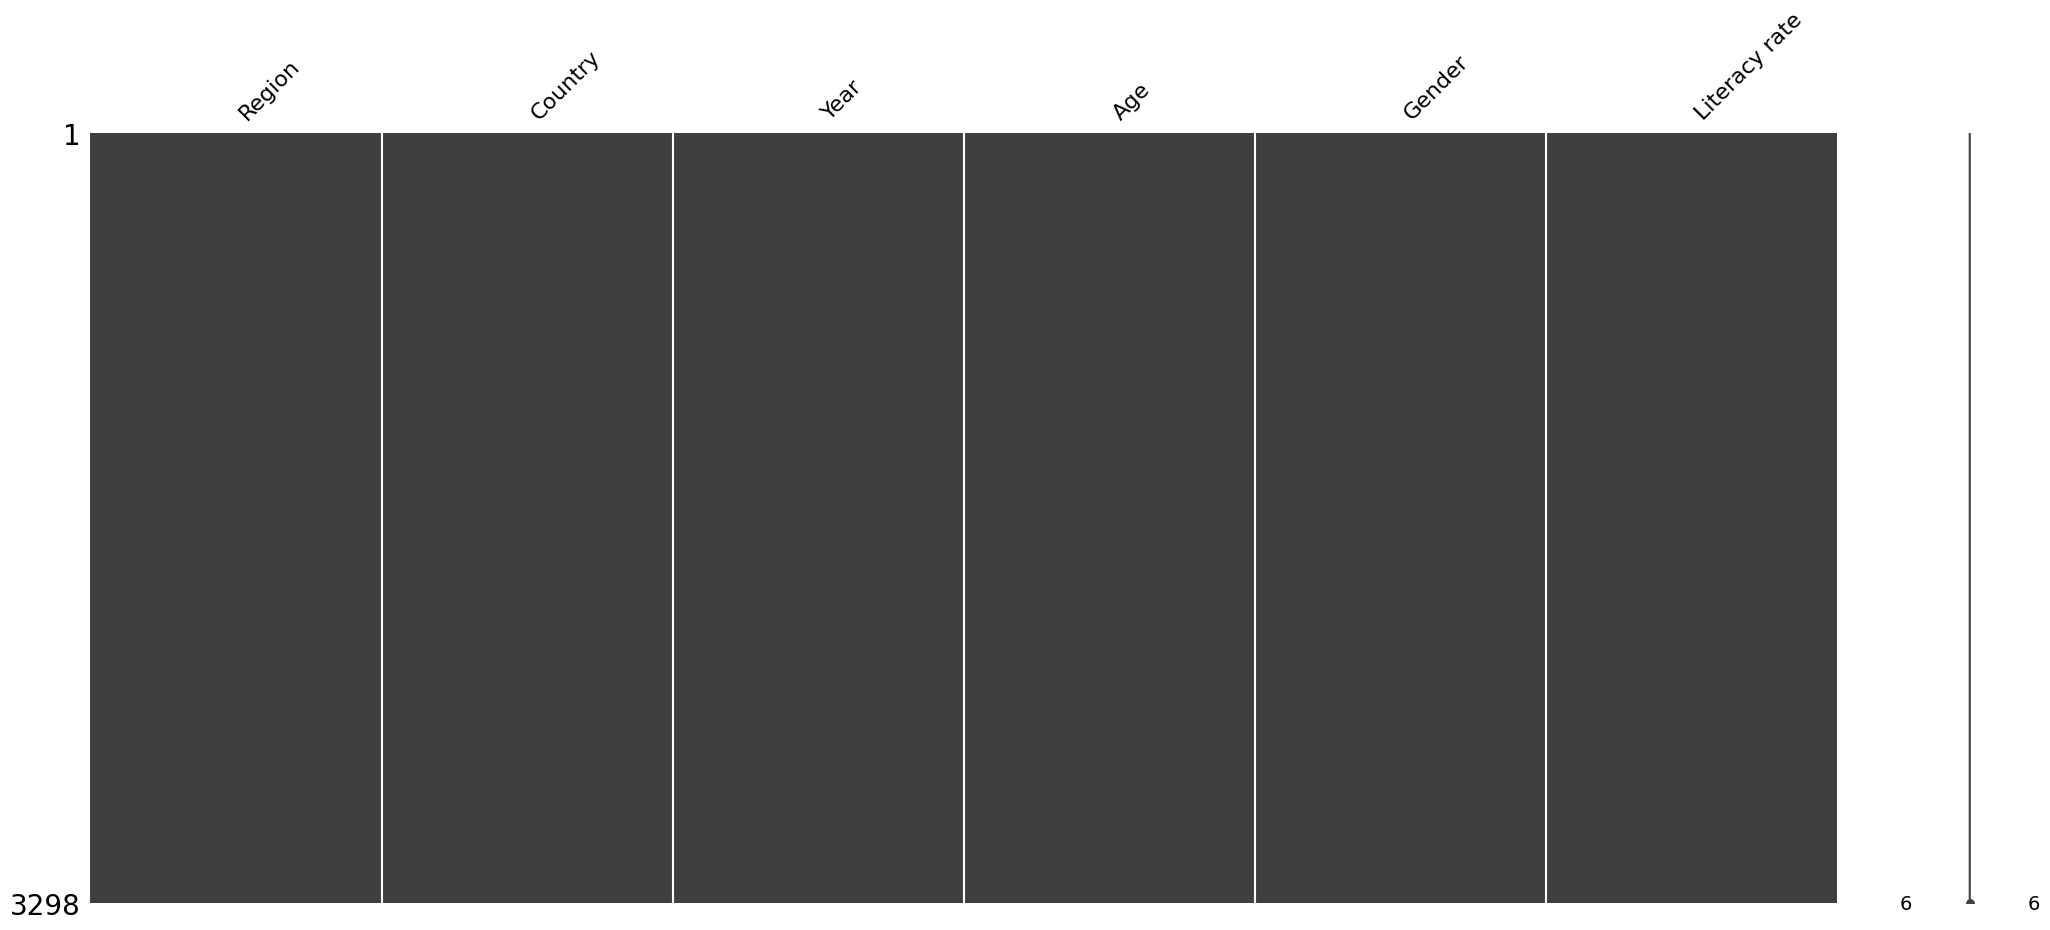

In [12]:
import missingno as msno
msno.matrix(df)

## Check Consistancy

In [13]:
# see the values for each column with it frequency to check the consistancy
for col in df.columns:
  print( df[col].value_counts())
  print('\n')

Region
Latin America and the Caribbean     940
Sub-Saharan Africa                  770
Northern Africa and Western Asia    568
Europe and Northern America         332
Central and Southern Asia           311
Eastern and South-Eastern Asia      281
Oceania                              96
Name: count, dtype: int64


Country
Uruguay                72
Mexico                 72
Brazil                 72
Palestine              64
Azerbaijan             64
                       ..
Guinea-Bissau           8
Niger                   8
Nigeria                 8
South Sudan             8
Antigua and Barbuda     4
Name: count, Length: 155, dtype: int64


Year
2018     574
2011     453
2014     439
2010     398
2012     343
2015     316
2016     264
2013     263
2017     246
2011_      1
3014       1
Name: count, dtype: int64


Age
<15      839
25-64    825
15-24    824
65+      810
Name: count, dtype: int64


Gender
female    1646
male      1645
F            4
M            3
Name: count, dtype: int

## Handling inconstancy

In [14]:
# replace the inconstancy values with the right values
df['Gender']=df['Gender'].replace({'F':'female','M':'male'})

In [15]:
# check to make sure that data now is clean
df['Gender'].value_counts()

,count
Gender,
female,1650
male,1648


In [16]:
df['Year']=df['Year'].replace({'2011_':2011 , 3014: 2014})

/tmp/ipykernel_445/2846950220.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Year']=df['Year'].replace({'2011_':2011 , 3014: 2014})


In [17]:
df['Year'].value_counts()

,count
Year,
2018,574
2011,454
2014,440
2010,398
2012,343
2015,316
2016,264
2013,263
2017,246


## Save the clean data

In [18]:
# save the clean data into new file called cleaning product sales using to_csv
fpath='/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week04/Data/Cleaning_literacy_rates.csv'
new_df=df.to_csv(fpath,index=False)


In [19]:
new_df=pd.read_csv(fpath)
new_df.head()

,Region,Country,Year,Age,Gender,Literacy rate
0,Central and Southern Asia,Afghanistan,2011,<15,female,0.176121
1,Central and Southern Asia,Afghanistan,2011,<15,male,0.454171
2,Central and Southern Asia,Afghanistan,2011,15-24,female,0.321132
3,Central and Southern Asia,Afghanistan,2011,15-24,male,0.618791
4,Central and Southern Asia,Afghanistan,2011,25-64,female,0.084128


#Exploratory Data Analysis

/tmp/ipykernel_445/981364261.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0][0].set_xticklabels(ax[0][0].get_xticklabels(),rotation=90);
/tmp/ipykernel_445/981364261.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0][1].set_xticklabels(ax[0][1].get_xticklabels(),rotation=90);
/tmp/ipykernel_445/981364261.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1][1].set_xticklabels(ax[1][1].get_xticklabels(),rotation=90);


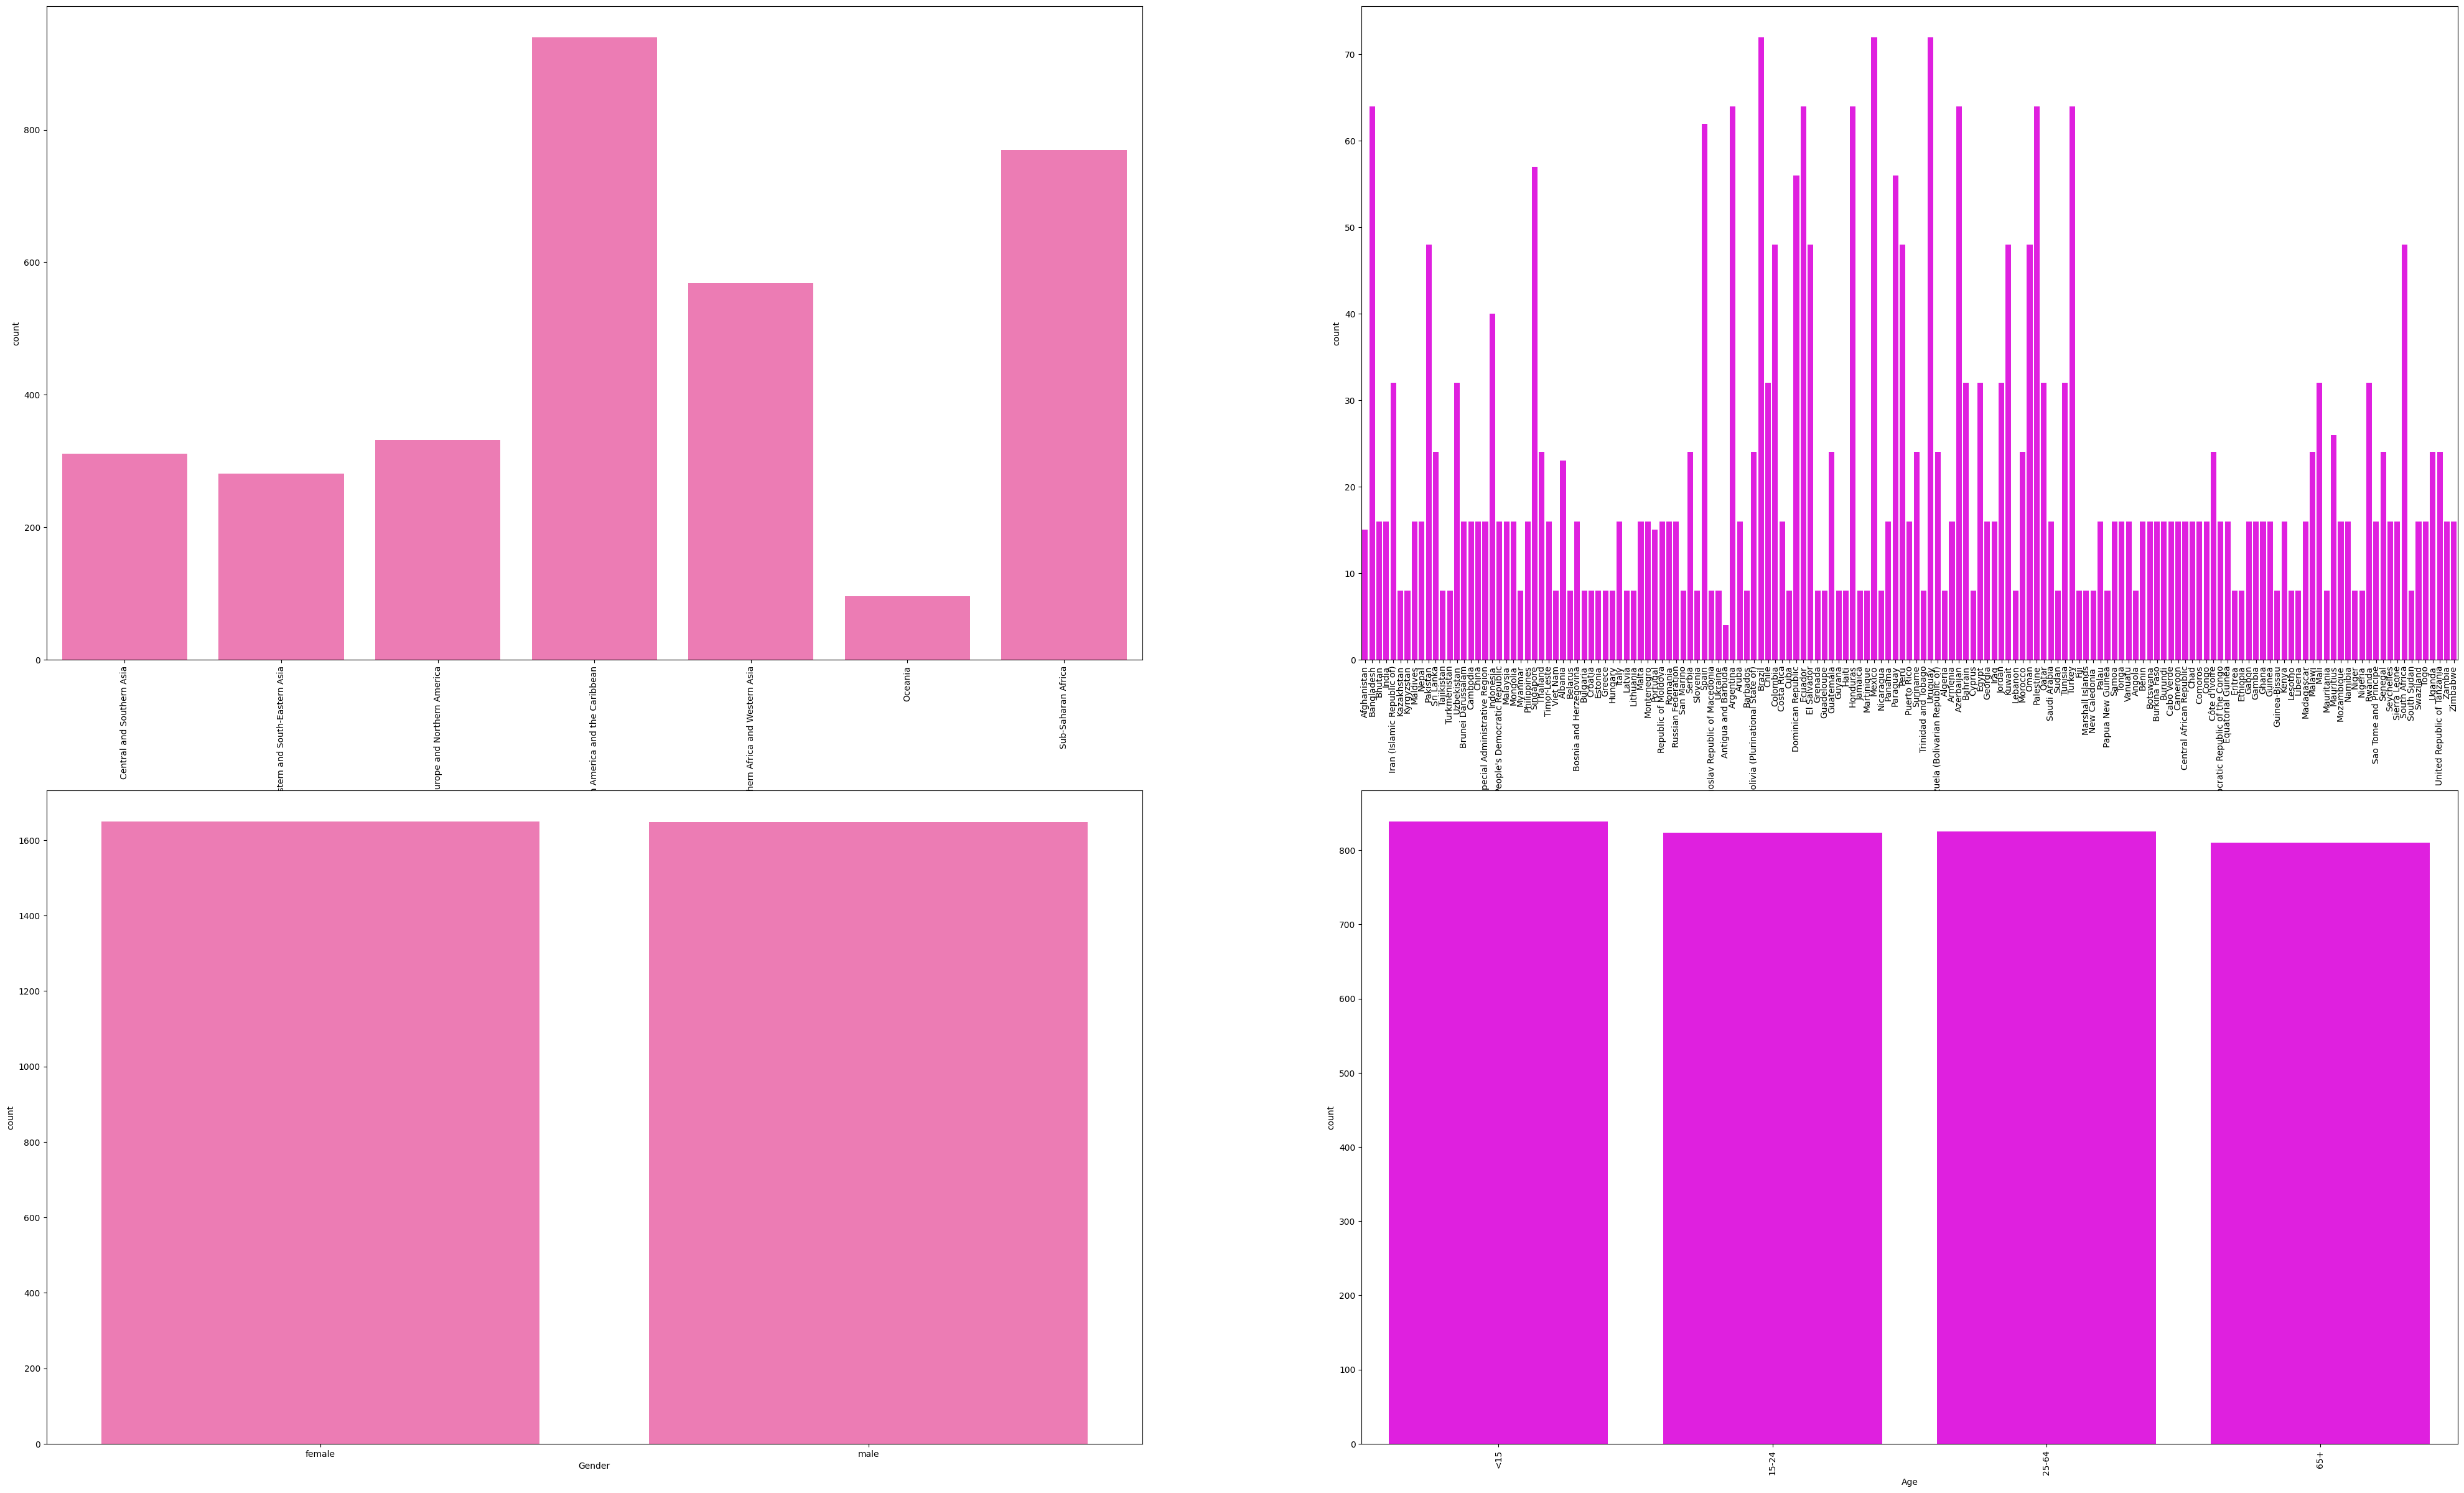

In [20]:
# draw a count plot to show the frequency of each category
# make a count plots for the categorical columns
fig,ax=plt.subplots(ncols=2,nrows=2,figsize=(50,30))
ax[0][0]=sns.countplot(x='Region',data=new_df,ax=ax[0][0],color='#FF69B4')
ax[0][0].set_title='count of Region '
ax[0][0].set_xticklabels(ax[0][0].get_xticklabels(),rotation=90);

ax[0][1]=sns.countplot(x='Country',data=new_df,ax=ax[0][1],color='#FF00FF')
ax[0][1].set_title='count of Countries'
ax[0][1].set_xticklabels(ax[0][1].get_xticklabels(),rotation=90);

ax[1][0]=sns.countplot(x='Gender',data=new_df,ax=ax[1][0],color='#FF69B4')
ax[1][0].set_title='count of Gender'

ax[1][1]=sns.countplot(x='Age',data=new_df,ax=ax[1][1],color='#FF00FF')
ax[1][1].set_title='count of Age '
ax[1][1].set_xticklabels(ax[1][1].get_xticklabels(),rotation=90);

/tmp/ipykernel_445/2426288360.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90);


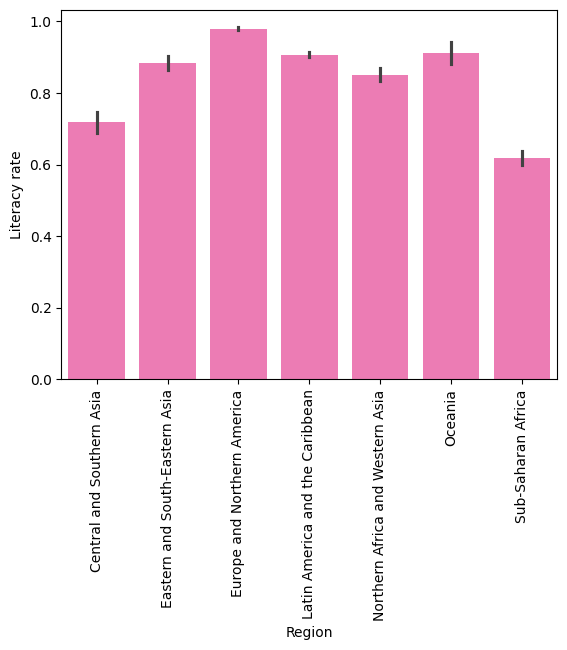

In [26]:
# make a bar plot for region vs Literacy rate
ax=sns.barplot(x='Region',y='Literacy rate',data=new_df,color='#FF69B4')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90);


/tmp/ipykernel_445/3264877960.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90);


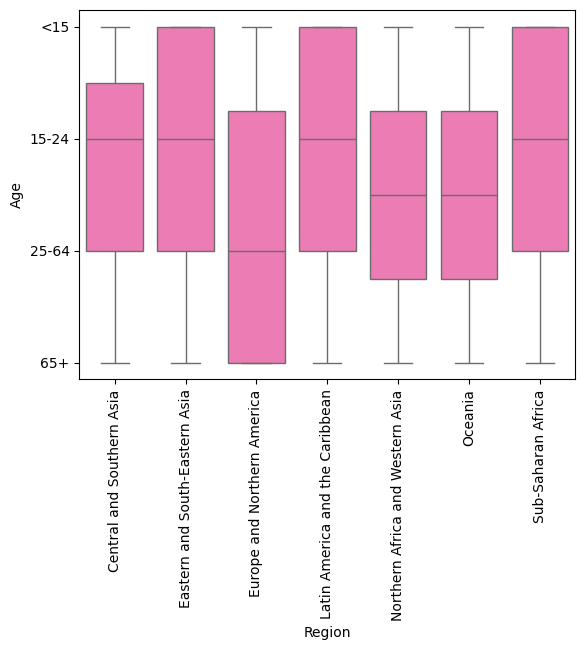

In [31]:
ax=sns.boxplot(x='Region',y='Age',data=new_df,color='#FF69B4')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90);